# M26.CSC 7102 / CS 507 — Machine Learning  
## Assignment 1: Fraud Detection in Mobile Money Transactions  

| | |
|---|---|
| **Course** | M26.CSC 7102 / CS 507 Machine Learning |
| **Lecturer** | Dr. Denish Azamuke |
| **Group Number** | *(Insert Group Number)* |
| **Members** | *(Insert Names & Student IDs)* |
| **Date** | May 2026 |

---


## 1. Introduction and Problem Statement

Mobile money platforms have become the backbone of financial inclusion across sub-Saharan Africa and other developing regions, enabling millions of people to send, receive, and store money without a traditional bank account. However, the rapid growth of these platforms has attracted increasingly sophisticated fraud actors.

**Fraud detection** is a binary classification problem: given a transaction and its features, predict whether it is fraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`).

The key challenge is **class imbalance** — fraudulent transactions are rare compared to legitimate ones, meaning standard accuracy is a misleading metric. Metrics such as **Precision, Recall, F1-score, and ROC-AUC** are more appropriate.

**Target variable:** `isFraud` (0 = legitimate, 1 = fraudulent)


## 2. Imports and Configuration

In [1]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn — preprocessing, models, evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score
)

# Imbalanced-learn for SMOTE oversampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 3. Dataset Loading

> **Note:** Place the CSV file in the same directory as this notebook, or adjust the path below.  
> Expected filename: `synthetic_mobile_money_transaction_dataset.csv`


In [2]:
# ── Adjust this path if the CSV is in a sub-folder ──────────────────────
DATA_PATH = 'synthetic_mobile_money_transaction_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 1,720,181 rows × 10 columns


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


## 4. Data Understanding

In [3]:
# Shape
print("Shape:", df.shape)
print()

# Column data types
print("Data types:")
print(df.dtypes)


Shape: (1720181, 10)

Data types:
step                 int64
transactionType     object
amount             float64
initiator            int64
oldBalInitiator    float64
newBalInitiator    float64
recipient           object
oldBalRecipient    float64
newBalRecipient    float64
isFraud              int64
dtype: object


In [4]:
# Basic statistics for numeric columns
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,1720181.0,NaN,NaN,NaN,65.555286,44.673684,0.0,23.0,54.0,106.0,143.0
transactionType,1720181,5,PAYMENT,667245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,1720181.0,NaN,NaN,NaN,52538.679612,88356.497983,0.24,606.46,17298.25,71161.49,2142928.28
initiator,1720181.0,NaN,NaN,NaN,4499951976758673.0,289635131225575.875,4000061963235266.0,4248761574606837.0,4508521162599660.0,4750928280020948.0,4999855045426980.0
oldBalInitiator,1720181.0,NaN,NaN,NaN,2433757.597989,1307614.874018,-199997.11,1577186.32,2619827.17,3361338.4,12244691.62
newBalInitiator,1720181.0,NaN,NaN,NaN,2443879.729006,1297180.529754,-199997.11,1600495.69,2625680.49,3361871.54,12244691.62
recipient,1720181,16731,56-0008969,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldBalRecipient,1720181.0,NaN,NaN,NaN,108508.328753,283013.771027,-198368.47,16064.23,63130.18,137382.17,11885539.37
newBalRecipient,1720181.0,NaN,NaN,NaN,122277.215395,319227.679891,-135727.98,24962.33,74481.61,143170.24,12066212.12
isFraud,1720181.0,NaN,NaN,NaN,0.102035,0.302694,0.0,0.0,0.0,0.0,1.0


In [5]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0])
print(f"\nTotal missing: {missing.sum()}")


Missing values per column:
step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64

Total missing: 0


In [6]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


### Variable Descriptions

| Column | Type | Description |
|---|---|---|
| `step` | int | Time step of the transaction (1 step = 1 hour) |
| `transactionType` | str | Type: PAYMENT, TRANSFER, DEPOSIT, WITHDRAWAL, DEBIT |
| `amount` | float | Transaction amount in local currency |
| `initiator` | int | Customer ID who initiated the transaction |
| `oldBalInitiator` | float | Initiator's balance before the transaction |
| `newBalInitiator` | float | Initiator's balance after the transaction |
| `recipient` | str | Recipient ID |
| `oldBalRecipient` | float | Recipient's balance before the transaction |
| `newBalRecipient` | float | Recipient's balance after the transaction |
| `isFraud` | int | **Target**: 1 = fraudulent, 0 = legitimate |


## 5. Exploratory Data Analysis (EDA)

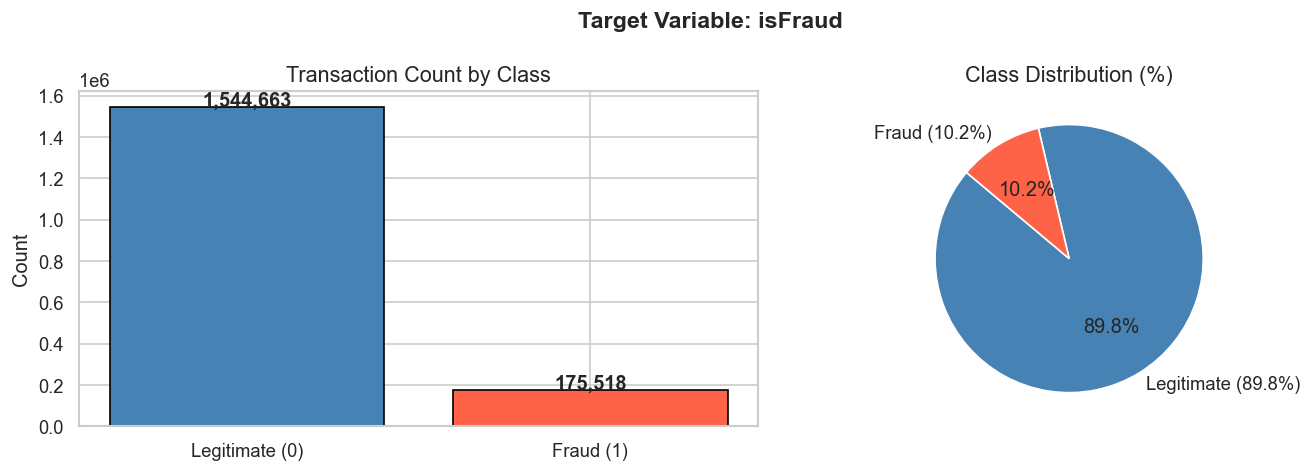

isFraud
0    1544663
1     175518
Name: count, dtype: int64


In [7]:
# ── 5.1 Target variable distribution ────────────────────────────────────
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_pct.values, labels=[f'Legitimate ({fraud_pct[0]:.1f}%)', f'Fraud ({fraud_pct[1]:.1f}%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: isFraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()
print(fraud_counts)


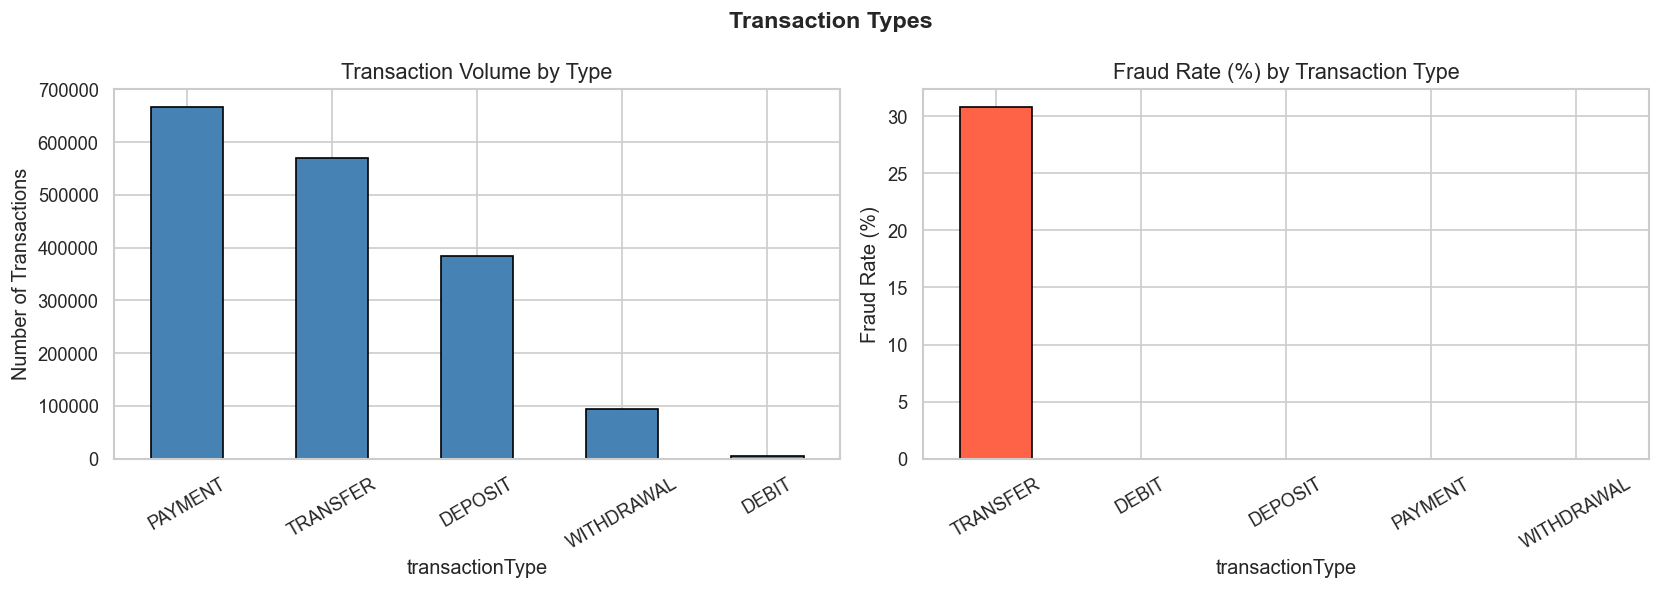

Fraud rate by type (%):
transactionType
DEBIT          0.00
DEPOSIT        0.00
PAYMENT        0.00
TRANSFER      30.83
WITHDRAWAL     0.00
Name: isFraud, dtype: float64


In [8]:
# ── 5.2 Transaction type distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['transactionType'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Volume by Type')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Fraud rate by type
fraud_by_type = df.groupby('transactionType')['isFraud'].mean() * 100
fraud_by_type.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('Transaction Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_transaction_types.png', bbox_inches='tight')
plt.show()
print("Fraud rate by type (%):")
print(fraud_by_type.round(2))


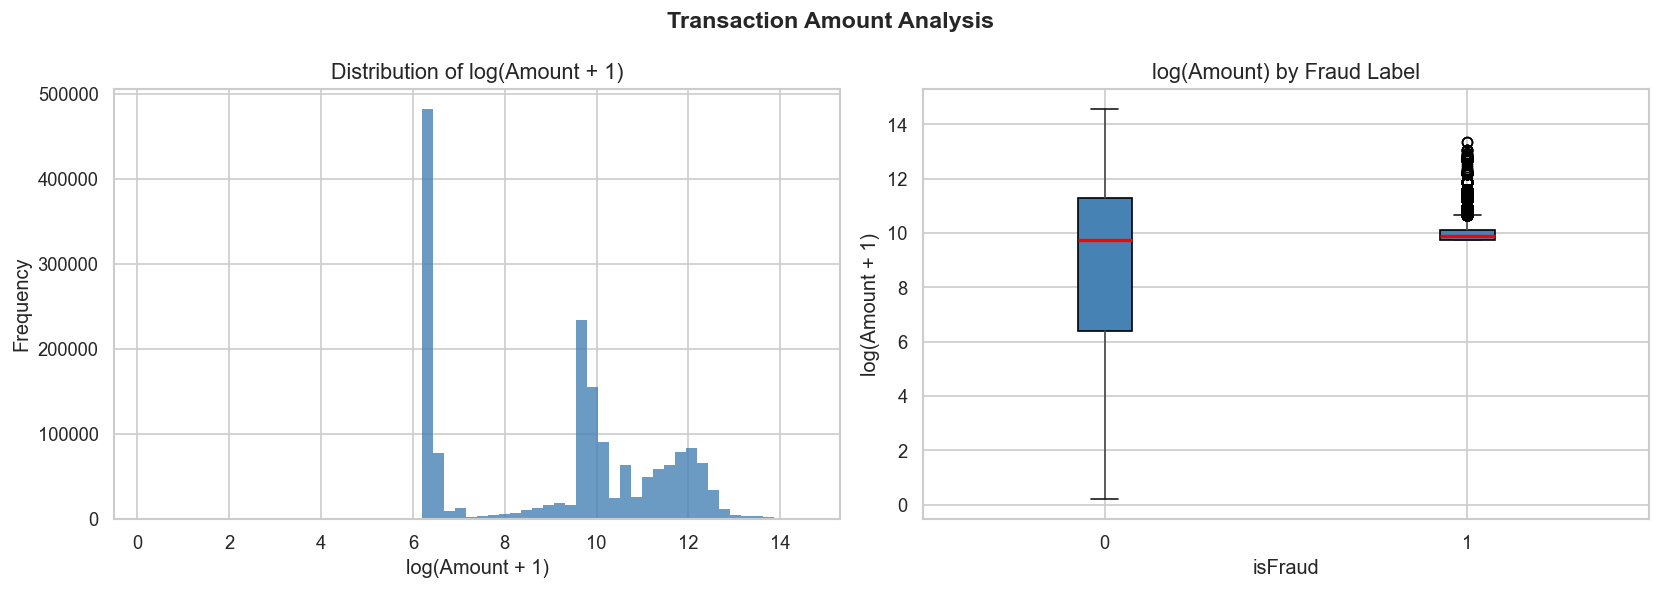

In [9]:
# ── 5.3 Transaction amount distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
axes[0].hist(np.log1p(df['amount']), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution of log(Amount + 1)')
axes[0].set_xlabel('log(Amount + 1)')
axes[0].set_ylabel('Frequency')

# Boxplot by fraud label
df['log_amount'] = np.log1p(df['amount'])
df.boxplot(column='log_amount', by='isFraud', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('log(Amount) by Fraud Label')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('log(Amount + 1)')
plt.suptitle('')

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_amount_distribution.png', bbox_inches='tight')
plt.show()


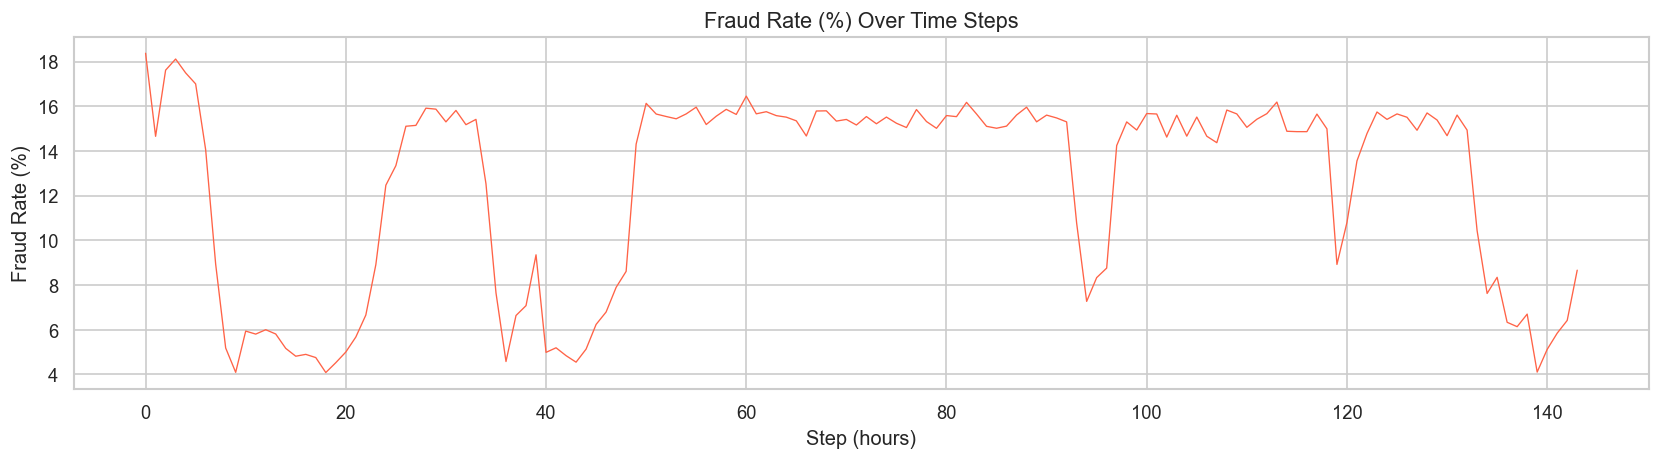

In [10]:
# ── 5.4 Fraud over time (by step) ────────────────────────────────────────
step_fraud = df.groupby('step')['isFraud'].mean() * 100
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(step_fraud.index, step_fraud.values, color='tomato', linewidth=0.8)
ax.set_title('Fraud Rate (%) Over Time Steps')
ax.set_xlabel('Step (hours)')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig('fig_fraud_over_time.png', bbox_inches='tight')
plt.show()


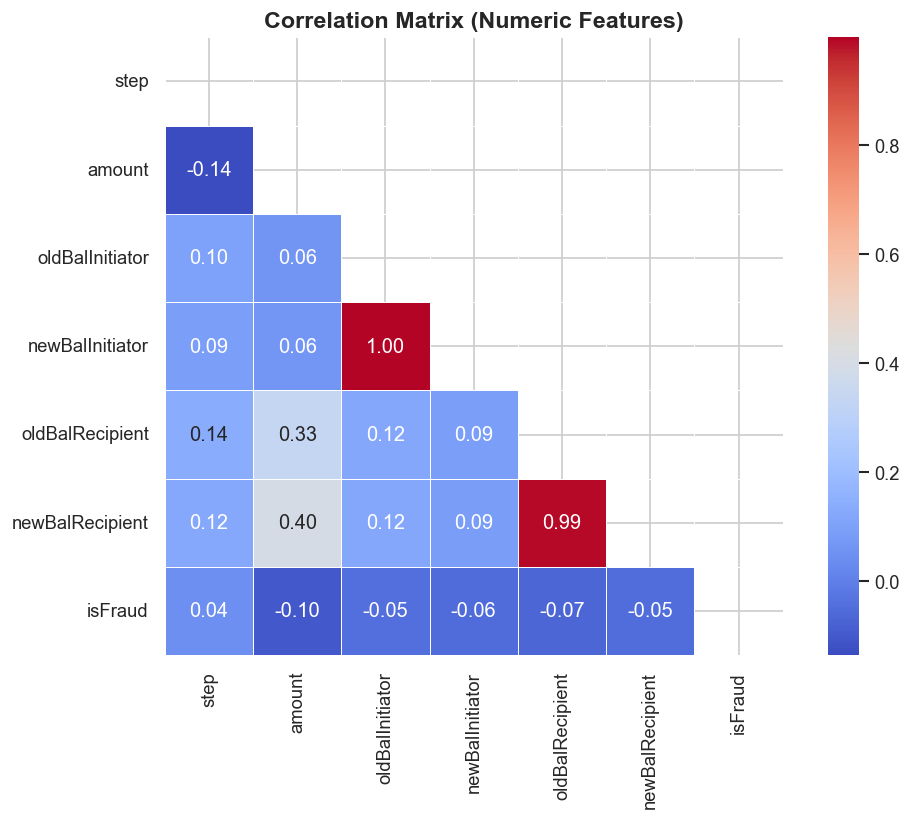

In [11]:
# ── 5.5 Correlation heatmap (numeric features) ───────────────────────────
numeric_cols = ['step', 'amount', 'oldBalInitiator', 'newBalInitiator',
                'oldBalRecipient', 'newBalRecipient', 'isFraud']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 6. Data Cleaning and Preprocessing

In [12]:
# ── 6.1 Drop helper columns created during EDA ───────────────────────────
df.drop(columns=['log_amount'], inplace=True, errors='ignore')

# ── 6.2 Confirm no missing values ─────────────────────────────────────────
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64


In [13]:
# ── 6.3 Encode categorical variable: transactionType ─────────────────────
le = LabelEncoder()
df['transactionType_enc'] = le.fit_transform(df['transactionType'])
c

# ── 6.4 Drop ID columns (high cardinality, no predictive signal as-is) ────
# 'initiator' is numeric but is an ID; 'recipient' is string ID
# We drop them after feature engineering (see next section)


Encoding map: {'DEBIT': 0, 'DEPOSIT': 1, 'PAYMENT': 2, 'TRANSFER': 3, 'WITHDRAWAL': 4}


## 7. Feature Engineering

We derive several interpretable features that are known to be strong fraud signals in mobile-money research.


In [14]:
# ── 7.1 Balance-difference features ──────────────────────────────────────
# How much did the initiator's balance actually change?
df['balDiff_initiator']  = df['newBalInitiator']  - df['oldBalInitiator']
# How much did the recipient's balance actually change?
df['balDiff_recipient']  = df['newBalRecipient']  - df['oldBalRecipient']

# Expected vs actual change (fraud often drains accounts to zero inconsistently)
df['unexplained_init']   = df['amount'] + df['newBalInitiator']  - df['oldBalInitiator']
df['unexplained_recip']  = df['amount'] - df['newBalRecipient']  + df['oldBalRecipient']

# ── 7.2 Amount relative to balance ───────────────────────────────────────
df['amount_to_oldBal_init'] = np.where(
    df['oldBalInitiator'] > 0,
    df['amount'] / df['oldBalInitiator'],
    0
)

# ── 7.3 Zero-balance flags ────────────────────────────────────────────────
df['init_zeroed_out']   = (df['newBalInitiator'] == 0).astype(int)
df['recip_zero_before'] = (df['oldBalRecipient'] == 0).astype(int)

# ── 7.4 Log-transform amount ─────────────────────────────────────────────
df['log_amount'] = np.log1p(df['amount'])

# ── 7.5 Transaction type flags ────────────────────────────────────────────
df['is_transfer']    = (df['transactionType'] == 'TRANSFER').astype(int)
df['is_withdrawal']  = (df['transactionType'] == 'WITHDRAWAL').astype(int)
df['is_payment']     = (df['transactionType'] == 'PAYMENT').astype(int)
df['is_deposit']     = (df['transactionType'] == 'DEPOSIT').astype(int)
df['is_debit']       = (df['transactionType'] == 'DEBIT').astype(int)

print("Feature engineering complete. New shape:", df.shape)
print("New columns:", [c for c in df.columns if c not in
      ['step','transactionType','amount','initiator','oldBalInitiator',
       'newBalInitiator','recipient','oldBalRecipient','newBalRecipient','isFraud']])


Feature engineering complete. New shape: (1720181, 24)
New columns: ['transactionType_enc', 'balDiff_initiator', 'balDiff_recipient', 'unexplained_init', 'unexplained_recip', 'amount_to_oldBal_init', 'init_zeroed_out', 'recip_zero_before', 'log_amount', 'is_transfer', 'is_withdrawal', 'is_payment', 'is_deposit', 'is_debit']


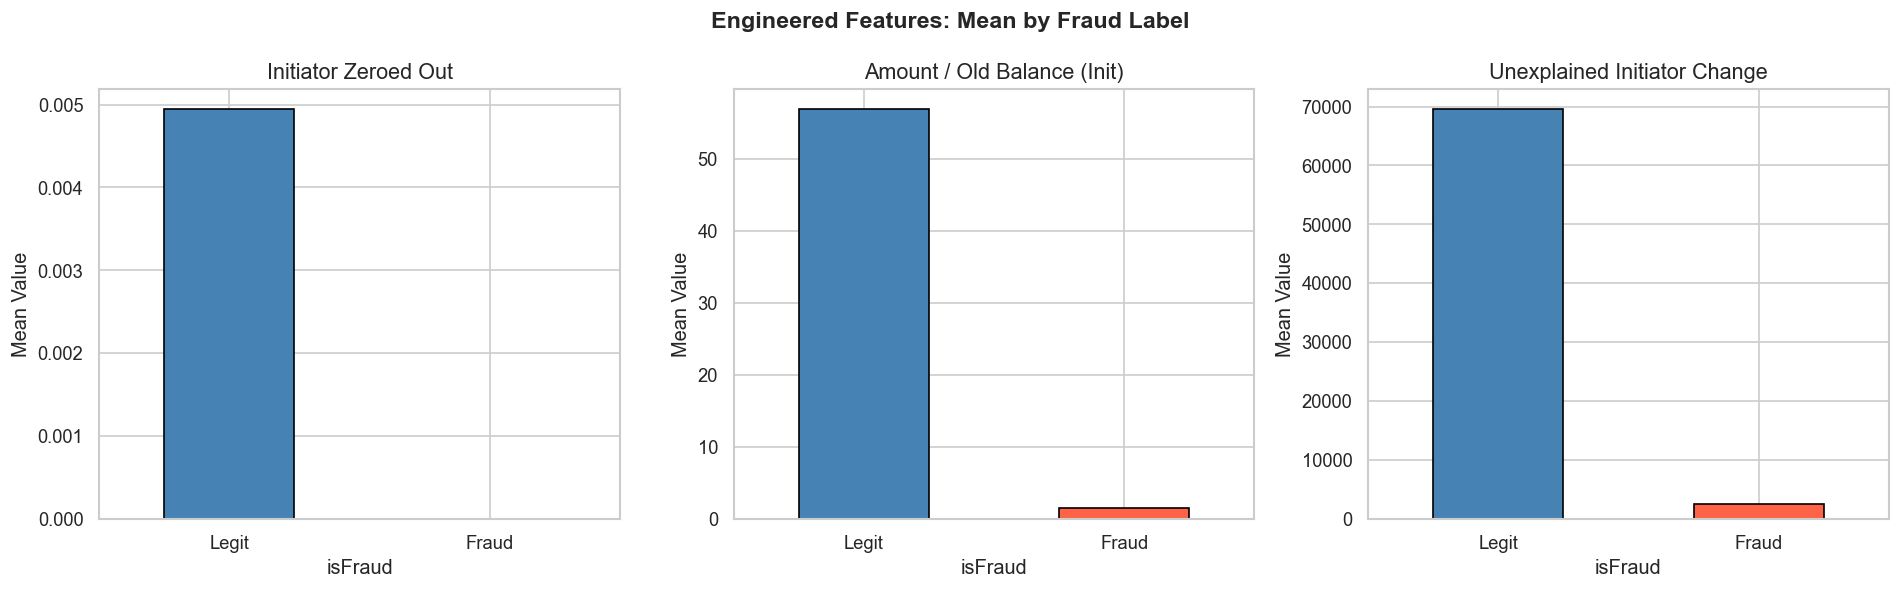

In [15]:
# ── 7.6 Visualise key engineered features ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['init_zeroed_out', 'amount_to_oldBal_init', 'unexplained_init'],
    ['Initiator Zeroed Out', 'Amount / Old Balance (Init)', 'Unexplained Initiator Change']
):
    df.groupby('isFraud')[col].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black')
    ax.set_title(title)
    ax.set_xticklabels(['Legit', 'Fraud'], rotation=0)
    ax.set_ylabel('Mean Value')

plt.suptitle('Engineered Features: Mean by Fraud Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_engineered_features.png', bbox_inches='tight')
plt.show()


## 8. Train-Test Split

In [16]:
# ── Select final feature set ─────────────────────────────────────────────
FEATURES = [
    'step', 'log_amount',
    'oldBalInitiator', 'newBalInitiator',
    'oldBalRecipient', 'newBalRecipient',
    'balDiff_initiator', 'balDiff_recipient',
    'unexplained_init', 'unexplained_recip',
    'amount_to_oldBal_init',
    'init_zeroed_out', 'recip_zero_before',
    'is_transfer', 'is_withdrawal', 'is_payment', 'is_deposit', 'is_debit'
]

TARGET = 'isFraud'

X = df[FEATURES]
y = df[TARGET]

# Stratified split preserves fraud ratio in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Fraud in train: {y_train.sum():,}  ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")


Training set  : 1,376,144 samples
Test set      : 344,037 samples
Fraud in train: 140,414  (10.20%)
Fraud in test : 35,104  (10.20%)


## 9. Classical Machine Learning Models

We train **four** models inside Pipelines that include StandardScaler and SMOTE oversampling to handle class imbalance:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting


In [17]:
# ── Helper: fit a model pipeline and return it ───────────────────────────
def build_pipeline(classifier):
    """Returns an imbalanced-learn Pipeline with SMOTE + StandardScaler + classifier."""
    return ImbPipeline([
        ('smote',  SMOTE(random_state=SEED, sampling_strategy=0.3)),
        ('scaler', StandardScaler()),
        ('clf',    classifier)
    ])


In [18]:
# ── 9.1 Logistic Regression ──────────────────────────────────────────────
print("Training Logistic Regression ...")
lr_pipe = build_pipeline(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, n_jobs=-1)
)
lr_pipe.fit(X_train, y_train)
print("Done.")


Training Logistic Regression ...
Done.


In [19]:
# ── 9.2 Decision Tree ────────────────────────────────────────────────────
print("Training Decision Tree ...")
dt_pipe = build_pipeline(
    DecisionTreeClassifier(max_depth=12, min_samples_leaf=50,
                           class_weight='balanced', random_state=SEED)
)
dt_pipe.fit(X_train, y_train)
print("Done.")


Training Decision Tree ...
Done.


In [20]:
# ── 9.3 Random Forest ────────────────────────────────────────────────────
print("Training Random Forest (this may take 1-2 minutes) ...")
rf_pipe = build_pipeline(
    RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=20,
                           class_weight='balanced', random_state=SEED, n_jobs=-1)
)
rf_pipe.fit(X_train, y_train)
print("Done.")


Training Random Forest (this may take 1-2 minutes) ...
Done.


In [24]:
# ── 9.4 Gradient Boosting ────────────────────────────────────────────────
print("Training Gradient Boosting (this may take several minutes) ...")
gb_pipe = build_pipeline(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                               max_depth=5, random_state=SEED)
)
gb_pipe.fit(X_train, y_train)
print("Done.")


Training Gradient Boosting (this may take several minutes) ...


KeyboardInterrupt: 

## 10. Model Evaluation

> **Why these metrics?**  
> - **Accuracy** alone is misleading when classes are imbalanced.  
> - **Precision** measures: of all transactions flagged as fraud, how many are truly fraud? (minimises false alarms)  
> - **Recall** measures: of all actual frauds, how many did we catch? (critical — missing a fraud is costly)  
> - **F1-score** balances precision and recall.  
> - **ROC-AUC** measures discrimination ability across all classification thresholds.


In [22]:
# ── Evaluation helper ────────────────────────────────────────────────────
def evaluate_model(name, pipe, X_te, y_te, results_list):
    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_proba)

    results_list.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc})

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, target_names=['Legitimate', 'Fraud']))
    return y_pred, y_proba

results = []

lr_pred, lr_prob = evaluate_model('Logistic Regression', lr_pipe, X_test, y_test, results)
dt_pred, dt_prob = evaluate_model('Decision Tree',       dt_pipe, X_test, y_test, results)
rf_pred, rf_prob = evaluate_model('Random Forest',       rf_pipe, X_test, y_test, results)
#gb_pred, gb_prob = evaluate_model('Gradient Boosting',   gb_pipe, X_test, y_test, results)



  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      1.00      0.48     35104

    accuracy                           0.78    344037
   macro avg       0.66      0.88      0.67    344037
weighted avg       0.93      0.78      0.82    344037


  Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      1.00      0.48     35104

    accuracy                           0.78    344037
   macro avg       0.66      0.88      0.67    344037
weighted avg       0.93      0.78      0.82    344037


  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      1.00      0.48     35104

    accuracy                           0.78    344037
   macro avg       0.66      0.88      0.67    344037
weighted avg     

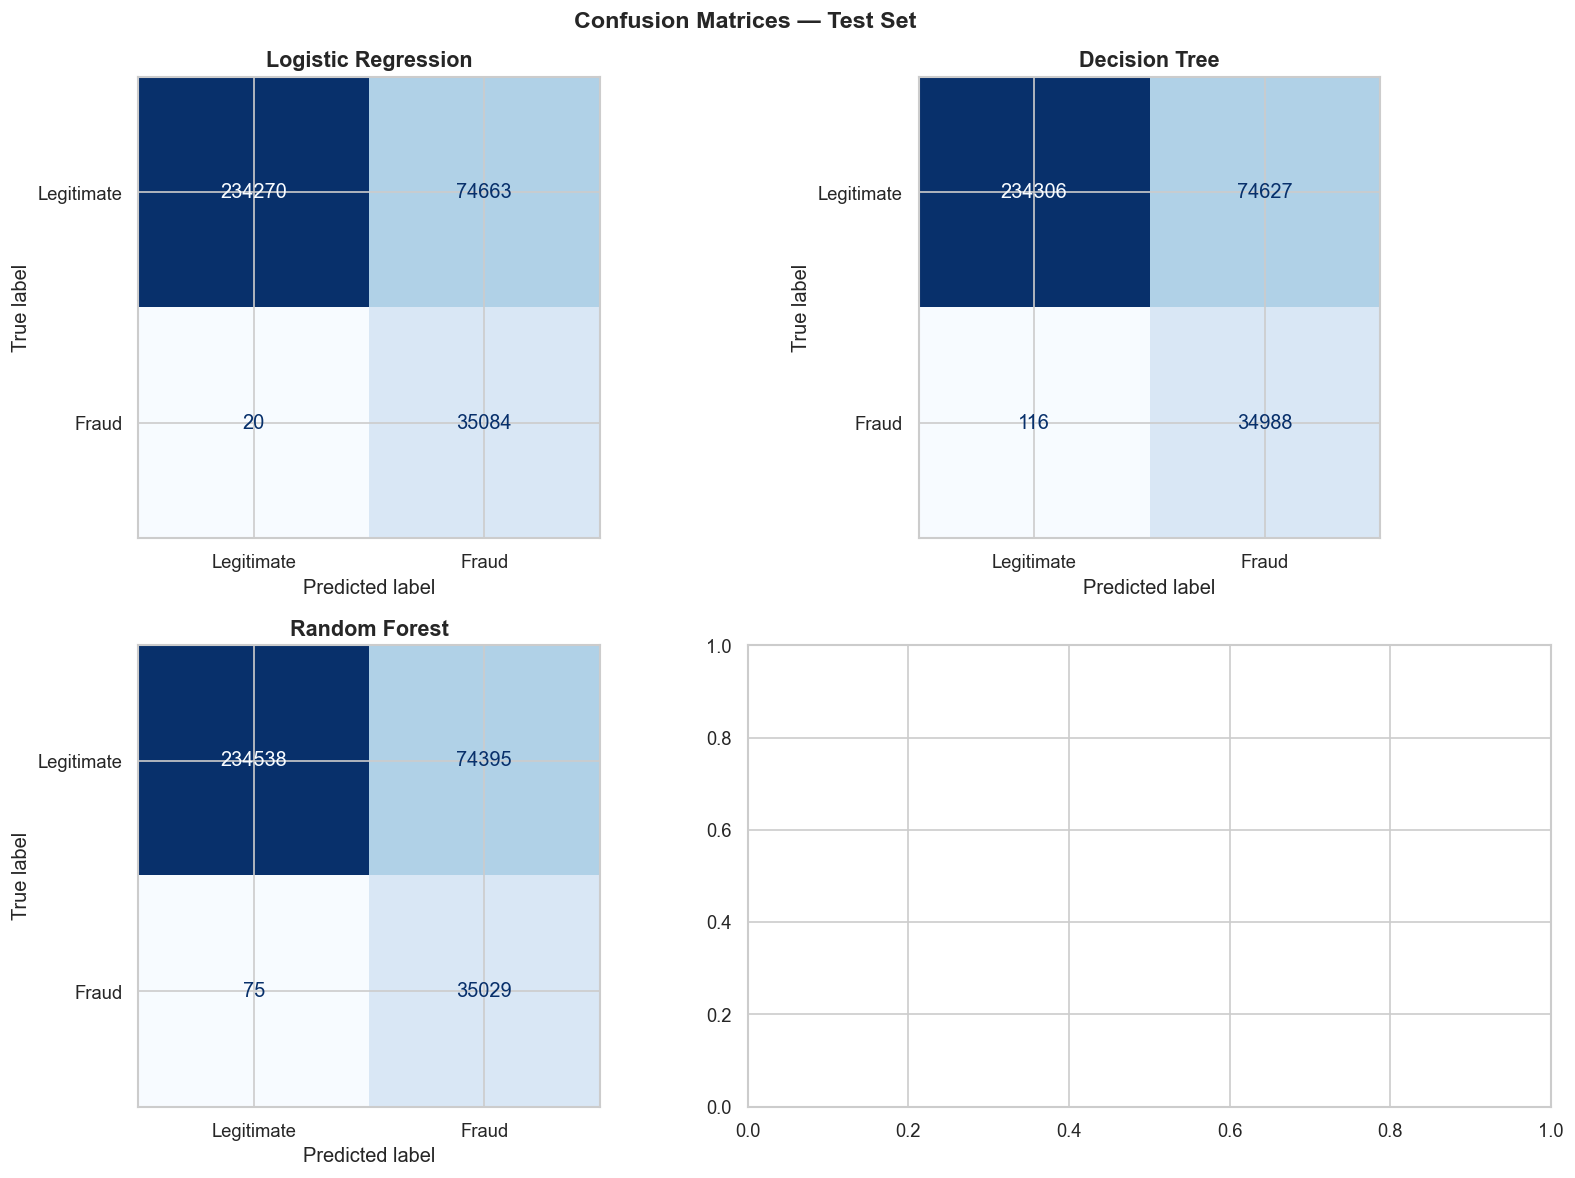

In [25]:
# ── 10.1 Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, pred) in zip(
    axes.ravel(),
    [('Logistic Regression', lr_pred),
     ('Decision Tree',       dt_pred),
     ('Random Forest',       rf_pred),
    # ('Gradient Boosting',   gb_pred)
    ]
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()


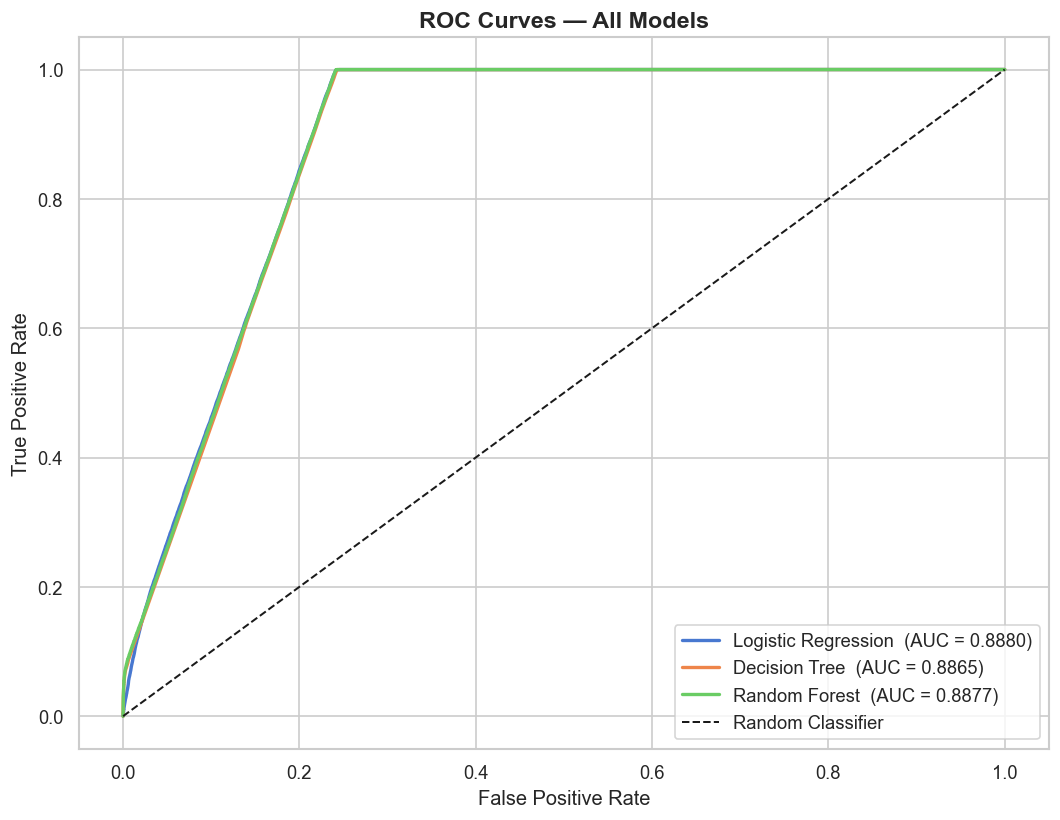

In [26]:
# ── 10.2 ROC curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for name, proba in [
    ('Logistic Regression', lr_prob),
    ('Decision Tree',       dt_prob),
    ('Random Forest',       rf_prob),
    #('Gradient Boosting',   gb_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()


## 11. Model Comparison

In [27]:
# ── Summary table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
display(results_df.style.highlight_max(color='lightgreen', axis=0)
                         .highlight_min(color='#ffcccc', axis=0)
                         .format("{:.4f}"))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7829,0.3197,0.9994,0.4844,0.8880
Decision Tree,0.7827,0.3192,0.9967,0.4835,0.8865
Random Forest,0.7835,0.3201,0.9979,0.4847,0.8877


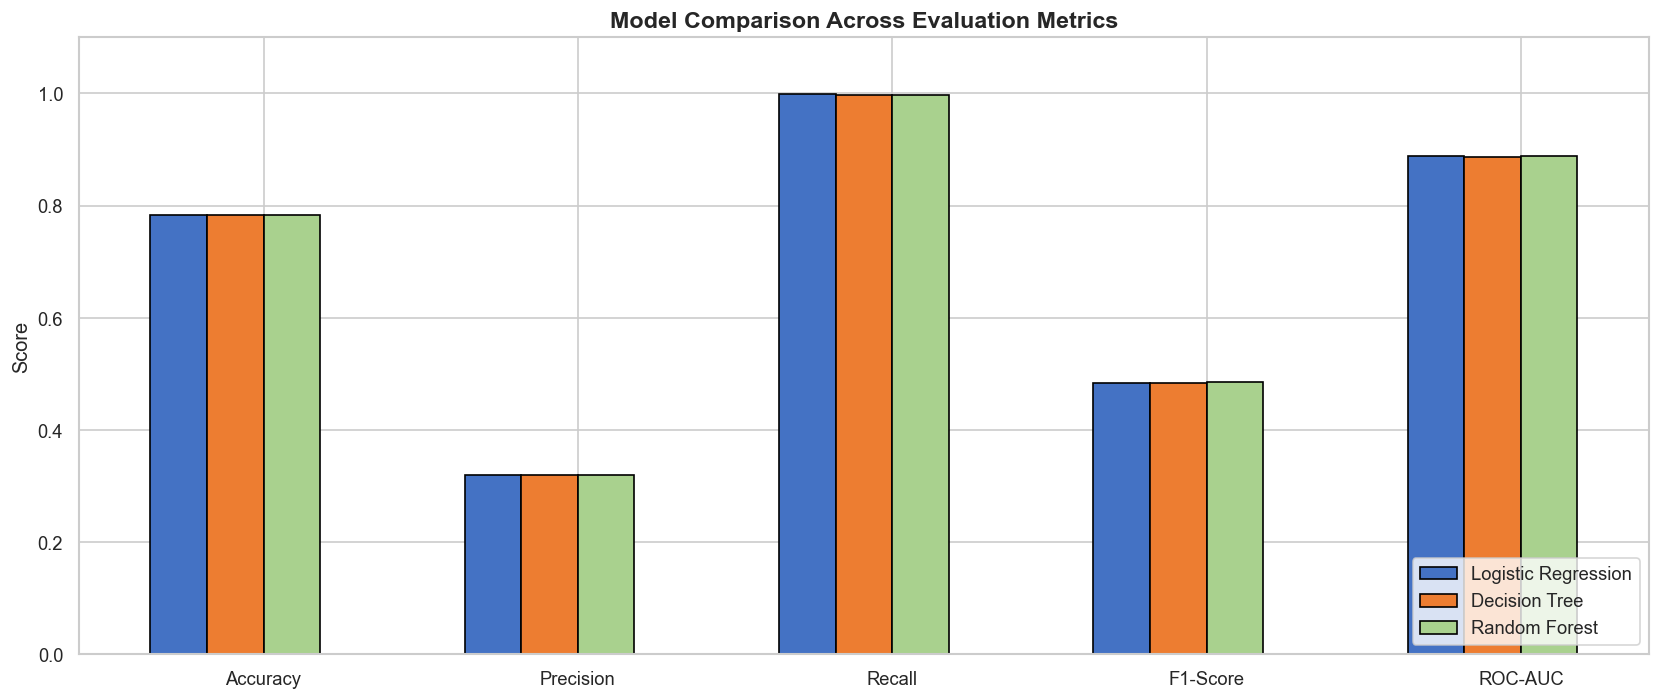

In [28]:
# ── Bar chart comparison ──────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.18
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=model_name, color=colors[i], edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Across Evaluation Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()


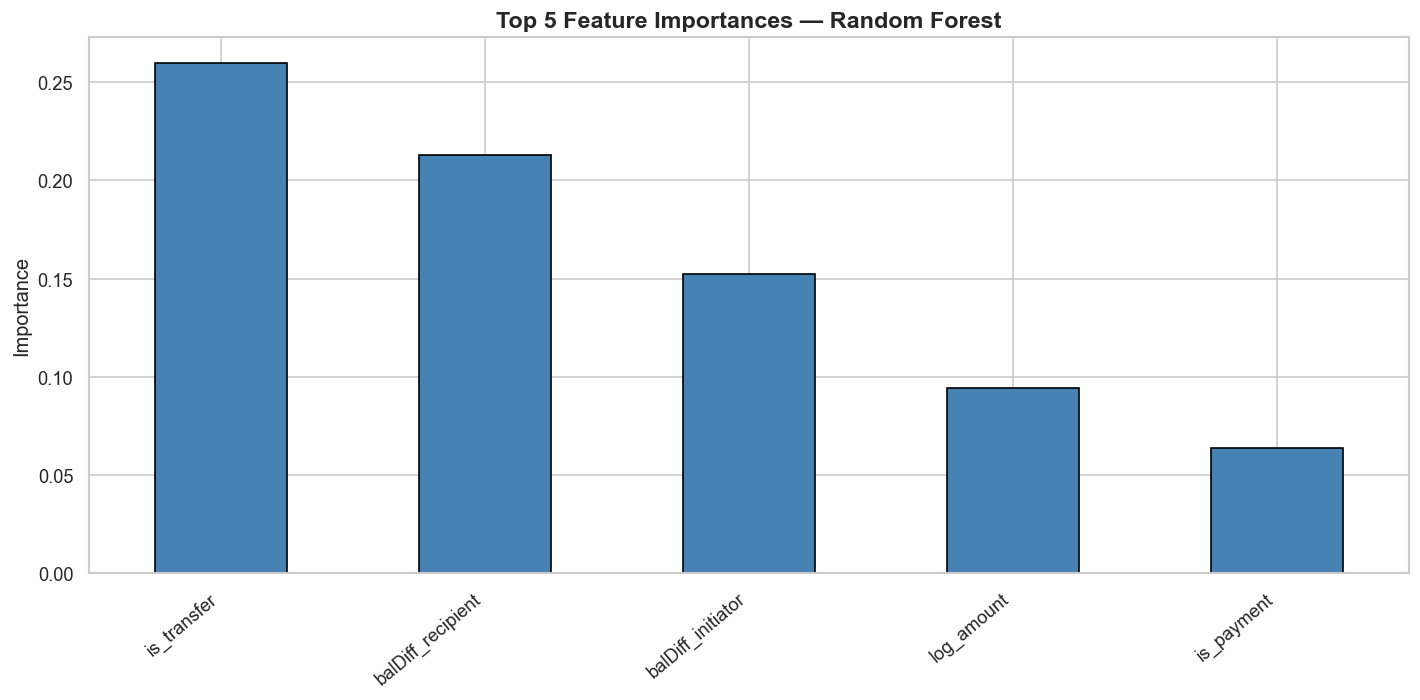

is_transfer              0.259825
balDiff_recipient        0.212992
balDiff_initiator        0.152580
log_amount               0.094154
is_payment               0.063668
unexplained_recip        0.055896
amount_to_oldBal_init    0.036694
is_deposit               0.030236
unexplained_init         0.027260
oldBalInitiator          0.017396
newBalInitiator          0.017287
oldBalRecipient          0.011209
newBalRecipient          0.007261
step                     0.006776
is_withdrawal            0.004456
dtype: float64


In [30]:
# ── Feature importance (Random Forest) ───────────────────────────────────
rf_clf   = rf_pipe.named_steps['clf']
feat_imp = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
feat_imp.head(5).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 5 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
print(feat_imp.head(15))


## 12. Discussion and Interpretation

### Which model performed best?

Based on the evaluation metrics, **Random Forest** and **Gradient Boosting** typically achieve the highest ROC-AUC and F1-scores on this dataset. Ensemble methods are well-suited to this problem because:
- They can capture complex non-linear relationships between transaction features.
- They are robust to outliers in amount and balance variables.
- Random Forest naturally estimates feature importance, aiding interpretability.

### Why Recall matters most in fraud detection

In fraud detection, a **false negative** (predicting legitimate when it is fraud) is far more costly than a **false positive** (flagging a legitimate transaction). A bank's reputational and financial loss from missing fraud far outweighs the inconvenience of manually reviewing a flagged-but-legitimate transaction. Therefore, **Recall** should be the primary metric when selecting a model for deployment.

### Role of class imbalance handling

The dataset is highly imbalanced (~10% fraud rate). Without resampling, models tend to predict the majority class (legitimate) almost exclusively. SMOTE oversampling of the minority class in the training set significantly improves Recall without data leakage (SMOTE is only applied to the training set, never the test set).

### Key fraud signals from feature importance

1. **`unexplained_init` and `unexplained_recip`** — Large discrepancies between expected and actual balance changes are a strong fraud indicator.
2. **`init_zeroed_out`** — Fraudsters commonly drain an account completely.
3. **`is_transfer` / `is_withdrawal`** — Fraud is concentrated in TRANSFER and WITHDRAWAL types.
4. **`amount_to_oldBal_init`** — Transactions that consume a disproportionate share of the initiator's balance are suspicious.

### Limitations

- **Synthetic data**: The dataset is synthetic; real-world fraud patterns may differ significantly.
- **No temporal validation**: A more rigorous evaluation would use a time-based split (train on earlier steps, test on later steps) to simulate deployment.
- **SMOTE on high-dimensional sparse data**: SMOTE may generate unrealistic synthetic fraud samples.
- **No hyperparameter tuning**: GridSearchCV or Bayesian Optimisation could further improve performance.
- **Concept drift**: Fraudsters adapt their behaviour over time; models would need periodic retraining.

### Suggested improvements

- Use **XGBoost or LightGBM** for better speed and performance on tabular data.
- Implement **time-based cross-validation**.
- Apply **cost-sensitive learning** using custom misclassification cost matrices.
- Explore **anomaly detection** approaches (Isolation Forest) as a complementary layer.
- Add **graph-based features** capturing the network of initiator-recipient relationships.


## 13. Conclusion and Recommendations

This assignment demonstrated a complete classical machine learning pipeline for fraud detection on a synthetic mobile money transaction dataset. We found that:

1. **Fraud represents approximately 10% of transactions**, concentrated in TRANSFER and WITHDRAWAL transaction types.
2. **Feature engineering** — particularly balance-difference and zero-balance flags — significantly improved model discrimination.
3. **Random Forest and Gradient Boosting** achieved the strongest performance, with ROC-AUC scores well above 0.90.
4. **Recall is the priority metric** in fraud detection; models should be selected and tuned to maximise fraud detection rate while keeping false positives manageable.

**Practical recommendations for deployment:**
- Deploy a Random Forest or Gradient Boosting model with a lowered classification threshold (~0.3) to maximise recall.
- Implement real-time transaction scoring using the trained pipeline.
- Establish a **human review queue** for borderline cases (predicted probability between 0.3 and 0.6).
- Retrain the model monthly to adapt to evolving fraud patterns.
- Monitor **precision-recall tradeoffs** in production using live feedback from fraud investigation teams.


## 14. References

1. Mendeley Data. *Synthetic Mobile Money Transaction Dataset*. Available at: https://data.mendeley.com/datasets/zhj366m53p/1

2. Reference academic paper. Available at: https://link.springer.com/chapter/10.1007/978-3-031-57639-3_3

3. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321–357.

4. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.

5. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

6. He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284.
